In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import yaml
from scipy import signal
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from datetime import datetime

In [6]:
datasets = [
    "20260319T0823-tof",
    "20260323T1344-tof",
    "20260320T1036-tysk",
    "20260325T1030-tysk",
    "20260324T1339-it1",
    "20260325T1030-tysk",
    "20260326T0815-tof",
    "20260327T0813-it1",
    "20260327T1030-tysk",
    "20260407T1333-it1",
    "20260408T1034-tysk",
    "20260409T0830-tof",
    "20260410T1027-tysk",
]

skip = 15
grouped = 400

final_dfs = []

for d in datasets:
    with open(f"{d}/meta.yaml") as file:
        meta = yaml.safe_load(file)
    
    dfs = []
    for i in range(meta["Arduinos"]):
        df = pd.read_csv(f"{d}/a{i+1}-data.csv")
        df["Sound"] = df["Sound"].rolling(300).mean()

        # Remove extreme values and the first and last few entries
        df = df.mask(lambda x: x < 2)
        df.loc[df["Humidity (%)"] > 90, "Humidity (%)"] = np.nan
        df.loc[df["Temperature (C)"] > 25, "Temperature (C)"] = np.nan
        df.loc[df["Temperature (C)"] < 15, "Temperature (C)"] = np.nan

        # Align all dataframes with the first one
        if i > 1:
            parameter = "Light"
            sig1 = dfs[0][parameter] - dfs[0][parameter].mean()
            sig2 = df[parameter] - df[parameter].mean()
            corr = signal.correlate(sig1, sig2, mode="full")
            lags = signal.correlation_lags(len(sig1), len(sig2), mode="full")
            best_lag = lags[np.argmad(corr)]
            df = df.shift(periods=best_lag)

        df = df[skip:-skip].copy()
        df = df.dropna()
        dfs.append(df)
    del meta["Arduinos"]

    df = pd.concat(dfs)
    df = df.groupby(df.index).mean()

    survey = pd.read_csv(f"{d}/survey.csv", header=0, names=["Timestamp", "Concentration", "Work"])
    del survey["Timestamp"]
    for col, mean in survey.mean().items():
        df[col] = mean

    for col, val in meta.items():
        df[col] = val
    df["Datetime"] = pd.to_datetime(
        df["Datetime"].str.split("-").str[0],
        format="%Y%m%dT%H%M"
    )
    df["Datetime"] += pd.to_timedelta(df["Timestamp"], unit="ms")
    del df["Timestamp"]
    
    final_dfs.append(df)

df = pd.concat(final_dfs)
df = df.set_index("Datetime", drop=True)

In [7]:
df

,Temperature (C),Humidity (%),Sound,Light,Concentration,Work,Room,Subject
Datetime,,,,,,,,
2026-03-19 08:38:00.844,20.340,39.645,15057.714850,362.0,3.625,3.125,619,tof
2026-03-19 08:38:03.844,20.340,39.650,15105.362467,363.5,3.625,3.125,619,tof
2026-03-19 08:38:06.844,20.340,39.660,15109.305283,363.0,3.625,3.125,619,tof
2026-03-19 08:38:09.844,20.335,39.670,15086.965050,363.0,3.625,3.125,619,tof
2026-03-19 08:38:12.844,20.330,39.655,15088.842217,362.0,3.625,3.125,619,tof
...,...,...,...,...,...,...,...,...
2026-04-10 11:32:54.603,19.600,30.640,12245.031333,153.0,4.500,2.500,413,tysk
2026-04-10 11:32:57.603,19.620,30.630,12373.936133,150.0,4.500,2.500,413,tysk
2026-04-10 11:33:00.603,19.620,30.620,12466.891700,149.0,4.500,2.500,413,tysk


<Axes: xlabel='Datetime'>

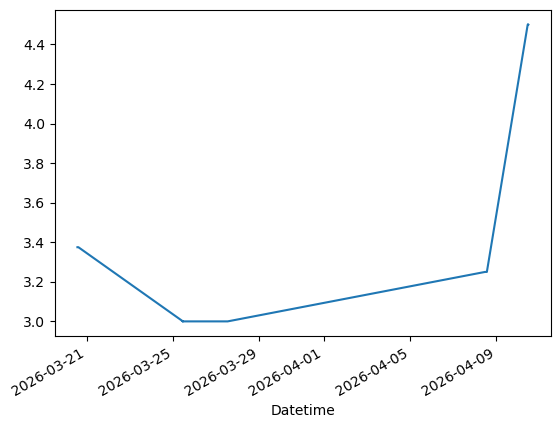

In [21]:
df_tysk = df[df["Subject"] == "tysk"]
df_tysk["Concentration"].plot()